In [1]:
import glob

from figures import *
from laser import *
from pipeline import *

# load spectrum
data_root = "/datax/scratch/ktp/carmenes-lasers/"
dir_list = glob.glob(data_root + "spectra/extracted/*")

diridx = 10

GOAL: inject lsf shaped laser into a spectrum

In [2]:
from load_data import load_star
save_dir = dir_list[diridx]

# load in data
(spec_arr, 
 cont_arr, 
 sigma_arr, 
 wave_arr, 
 obj, 
 ra, 
 dec, 
 date_arr, 
 exptime_arr, 
 airm_arr, 
 bary_corr_arr) = load_star(save_dir, print_headers=False, print_flux_headers=False)

# load in resamples
new_wave_path = save_dir + "/resampled_wave.npy"
new_spec_path = save_dir + "/resampled_spec.npy"
new_sig_path = save_dir + "/resampled_sig.npy"

new_wave_arr = np.load(new_wave_path, allow_pickle=True)
new_spec_arr = np.load(new_spec_path, allow_pickle=True)
new_sig_arr = np.load(new_sig_path, allow_pickle=True)

# load in polyfits
results = resample_and_fit(wave_arr, 
                    spec_arr, 
                    sigma_arr,
                    bary_corr_arr, 
                    save_dir, 
                    criterion="AIC")

(new_wave_arr,
               normalized_spec, 
               normalized_sig,
               poly_arr_best, 
               nopoly_arr_best, 
               bin_midpts_arr_best, 
               bin_meds_arr_best, 
               bic_vals, 
               deg_vals, 
               high_std_mask
) = results

processing degree 1
processing degree 2
processing degree 3
processing degree 4
processing degree 5


There are 369 peaks
[2.46983416e-320 2.24022402e-002             nan]
There are 6 peaks broader than the LSF
There are 6 peaks broader than the min LSF
They are at [6532.79667967 6536.24662466 6541.16391639 6542.77687769 6543.00090009
 6599.99219922]
0.02800280027986446


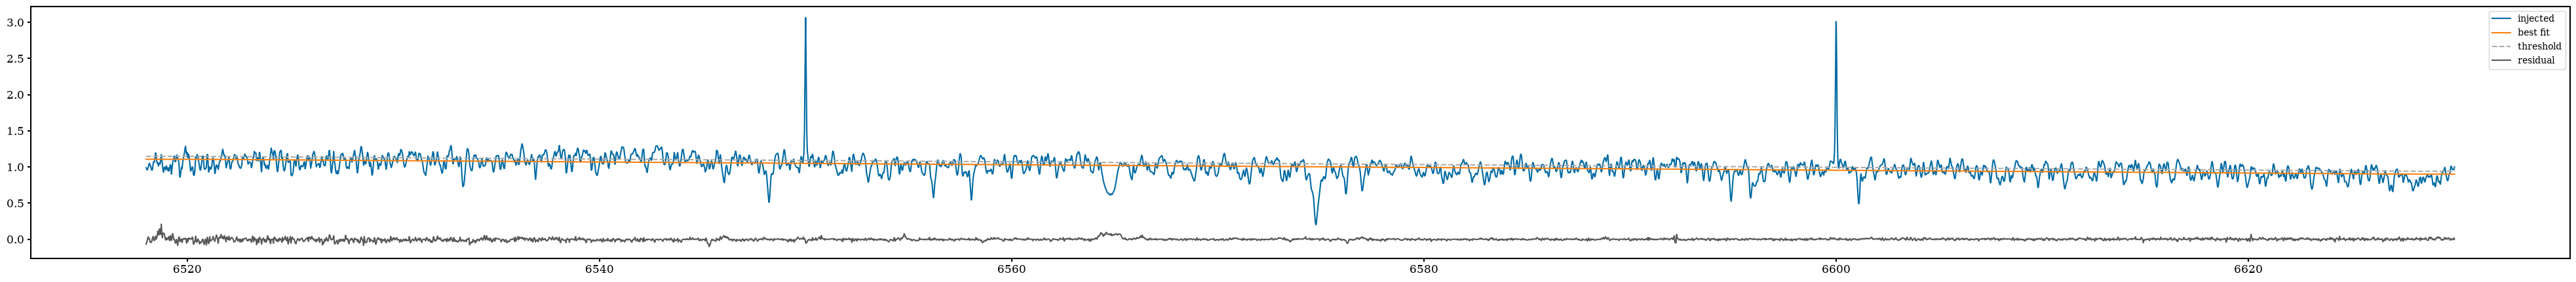

In [4]:
residual_arr = get_residual(normalized_spec)
laser_arr = make_laser_arr(new_wave_arr, normalized_spec, poly_arr_best, 
                           mult=3, broaden_coeff=1, set_fwhm_px=2.5,
                           model_type="astropy")
normalized_laser_arr = laser_arr / poly_arr_best

ordidx = 25
obsidx = 1
coeff = 6

injected_laser = normalized_laser_arr + normalized_spec 
wave = new_wave_arr[ordidx, :, obsidx]
flux = injected_laser[ordidx, :, obsidx]
# flux = normalized_spec[ordidx, :, obsidx]
poly = poly_arr_best[ordidx, :, obsidx]
residual = residual_arr[ordidx, :, obsidx]
sigma = normalized_sig[ordidx, :, obsidx]

## this is per order
(fwhms, x_peaks, 
 half_maxes, flx_pks, 
 threshold, wave, flux, poly, residual) = wave_to_fwhms(wave, 
                      flux, 
                      poly,
                      residual,
                      coeff, 
                      max_diff=0.1, 
                    threshold_type="mad", 
                    interp_samples=10000,
                    verbose=False)

print(f"There are {len(fwhms)} peaks")
# print(f"There are at {x_peaks}")

fwhm_lsfs = fwhm_test(wave, x_peaks, method="model", px_min=None)
print(fwhm_lsfs)
print(f"There are {len(fwhms[fwhms > fwhm_lsfs[1]])} peaks broader than the LSF")

wl_min = fwhm_test(wave, x_peaks, method="pixel", px_min=2.5)
print(f"There are {len(fwhms[fwhms > wl_min])} peaks broader than the min LSF")
print(f"They are at {x_peaks[fwhms > wl_min]}")
print(wl_min)

# print(fwhms[fwhms > wl_min])
fig = plt.figure(figsize=(50, 5))
plt.plot(wave, flux, label="injected")
plt.plot(wave, poly, label="best fit")
plt.plot(wave, threshold, linestyle="dashed", label="threshold")
plt.plot(wave, residual, label="residual")

plt.legend()

In [5]:
from tqdm import tqdm

## runs wave_to_fwhms on all orders, obs

flux_arr = injected_laser
coeff = 6
#args: (new_wave_arr, flux_arr, poly_arr_best, residual_arr, normalized_sig)

fwhm_arr = get_fwhm_arr(new_wave_arr, flux_arr, 
                 poly_arr_best, residual_arr, 
                 normalized_sig, coeff, interp_samples=10000)

100%|███████| 61/61 [00:02<00:00, 22.58it/s]


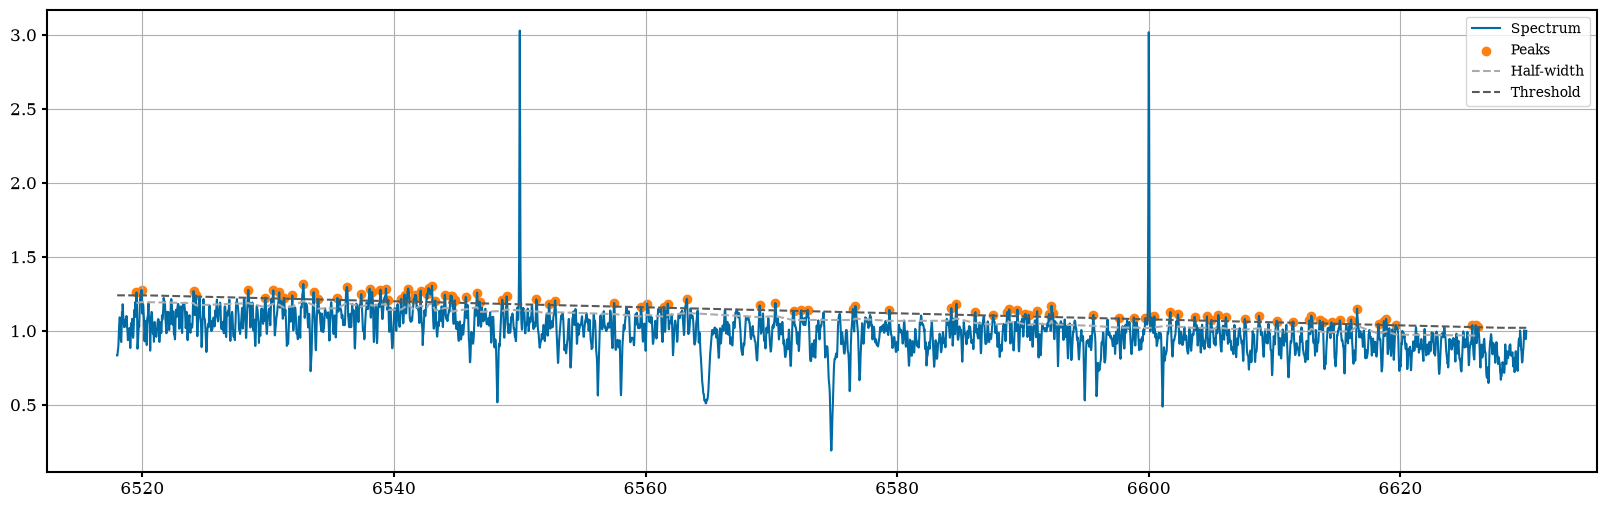

In [6]:

plot_ordobs_peaks(fwhm_arr, ordidx=25, obsidx=0)

plt.show()

In [ ]:
from tqdm import tqdm

coeffs = np.arange(1, 20, 1)
candidates = []

for coeff in tqdm(coeffs): 
    all_x_peaks_arr =  get_x_peaks_arr(new_wave_arr,
                   injected_laser,
                   poly_arr_best,
                   residual_arr, 
                   normalized_sig,
                   coeff, interp_samples=10000)
    candidates.append(len(all_x_peaks_arr))

candidates = np.array(candidates)

plt.plot(coeffs, candidates)
plt.xticks(coeffs)
plt.xlabel("AMD Coefficient")
plt.ylabel("# Candidates")
plt.ylim(0)
plt.grid()
plt.show()

 16%|█▎      | 3/19 [00:28<02:19,  8.69s/it]

In [ ]:
residual_fraction = np.abs(residual_arr/normalized_spec)

plot_spectra_ords(new_wave_arr, 
                 residual_fraction, 
                  figsize=(36, 20),
                 data2_label="Residual")

plt.show()

residual_fraction_limit = 0.5

all_wave_cols = residual_fraction.flatten()
n_wavecols = all_wave_cols.shape[0]

all_high_err = all_wave_cols[all_wave_cols > residual_fraction_limit]
n_high_err = all_high_err.shape[0]

# print("fraction of large residuals:", n_high_err/n_wavecols)



In [ ]:
# wls = np.arange(5200, 10400, 50)
wls = np.random.uniform(low=5200, high=10400, size=(50,))

laser_arr = make_laser_arr(new_wave_arr, normalized_spec, poly_arr_best, 
                           mult=1.5, broaden_coeff=1.1, wls=wls,
                           model_type="astropy")
normalized_laser_arr = laser_arr / poly_arr_best

all_x_peaks_arr =  get_x_peaks_arr(new_wave_arr,
                   injected_laser,
                   poly_arr_best,
                   residual_arr, 
                   normalized_sig,
                   coeff=6, interp_samples=10000)

recovereds = []
tolerances = np.logspace(-4, 0)
for tolerance in tolerances:
    matched_fwhms = []
    for target_wl in wls:
        # Find FWHMs within tolerance
        mask = np.abs(all_x_peaks_arr - target_wl) <= tolerance
        if np.any(mask):
            # Pick closest among valid candidates
            valid_indices = np.where(mask)[0]
            closest_idx = valid_indices[np.argmin(np.abs(all_x_peaks_arr[valid_indices] - target_wl))]
            matched_fwhms.append(all_x_peaks_arr[closest_idx])
        else:
            matched_fwhms.append(np.nan)  # No match within tolerance
    
    matched_fwhms = np.array(matched_fwhms)
    n_recovered = len(matched_fwhms[~np.isnan(matched_fwhms)])
    recovereds.append(n_recovered)

recovereds = np.array(recovereds)
# print(len(all_x_peaks_arr), "candidates")
# print(len(wls), "injected")
# print(, "recovered")
# print(len(matched_fwhms[~np.isnan(matched_fwhms)])/len(wls), "recovery rate")

# print(wls)
# print(matched_fwhms)

In [ ]:
plt.plot(tolerances, recovereds / 104)
plt.xscale("log")
plt.grid()
plt.ylabel("% Recovered Injections")
plt.xlabel("Allowed $\AA$ Away from Injection")
plt.show()
# print(tolerances)

In [ ]:
fwhms, x_peaks, half_maxes, flx_pks, threshold, _, _, _, _ = wave_to_fwhms(wave, 
                      normalized_laser_arr[ordidx, :, obsidx], 
                      np.zeros_like(wave),
                      np.zeros_like(wave),
                      coeff, 
                      max_diff=0.1, threshold_type="std", 
                      verbose=False, interp_samples=10000)


fwhm_lsfs = fwhm_test(wave, x_peaks, method="model", px_min=None)
print(x_peaks)
print(f"There are {len(fwhms[fwhms >= fwhm_lsfs[1]])} peaks broader than the LSF")

In [ ]:
ords = [5, 25, 56]
wls = [5400, 6600, 9850]
obsidx = 1

all_results = []
for i, ordidx in enumerate(ords): 
    wave = new_wave_arr[ordidx, :, obsidx]
    wl = wls[i]

    print(f'Order {ordidx} at {wl} angstrom')
    v1 = lsf_per_wav(wave, wl, 
                w_lorentz=np.array([0.28, 0.21, 0.17]) * 1e-5, 
                w_gauss=np.array([1.0, 1.01, 1.18]) * 1e-5)

    plt.plot(wave, v1)
    
    results = wave_to_fwhms(wave, v1, 
                               np.zeros_like(wave), 
                               np.zeros_like(wave), 
                               0, interp_samples=10000,
                            max_diff=0.1,
                            verbose=True)

    plt.plot(results[5], results[6])
    plt.show()

    all_results.append(results)
    

In [ ]:
for i, result in enumerate(all_results):
    (fwhms, x_peaks, half_maxes, 
                flx_pks, threshold, 
                wave, flux, poly, residual) = result  
    print("wl, fwhm ang", x_peaks[0], fwhms[0])

    wave = new_wave_arr[ords[i], :, obsidx]
    pixels = np.linspace(0, len(wave), len(wave))

    # px_of_wave = np.polyfit(wave, pixels, 1)
    # p = np.poly1d(px_of_wave)

    wave_of_px = np.polyfit(pixels, wave, 1)
    g = np.poly1d(wave_of_px)

    difference_array = np.absolute(wave - x_peaks[0])
    index = difference_array.argmin()
    
    print("expected 2.5 px fwhm in wl", g(index + 1.25) - g(index - 1.25))
    # print("fwhm in px", 
    #       p(x_peaks[0] + 0.5*fwhms[0]) - p(x_peaks[0] - 0.5*fwhms[0]))

In [ ]:
# args: (new_wave_arr, wls, )
# need some way to identify which order wl is in

for i in range(len(wls)):
    wave = new_wave_arr[ords[i], :, obsidx]
    pixels = np.linspace(0, len(wave), len(wave))

    wave_of_px = np.polyfit(pixels, wave, 1)
    g = np.poly1d(wave_of_px)

    difference_array = np.absolute(wave - x_peaks[0])
    index = difference_array.argmin()
    
    print("expected 2.5 px fwhm in wl", g(index + 1.25) - g(index - 1.25))

In [ ]:
from scipy.signal import find_peaks
import numpy as np

peaks_list, skipped_peaks = extract_peaks_between_minima(wave, flux, sigma, x_peaks[fwhms > wl_min])

In [ ]:
print(0.5 + np.sqrt(5/4))
print((0.5 + np.sqrt(5/4))*2)

In [ ]:
from lmfit.models import VoigtModel
from astropy.modeling.models import Voigt1D

from pipeline import reduced_chi2

# idx=11
for idx in range(len(peaks_list)):
    wave_peak, flux_peak, sigma_peak = peaks_list[idx]  
    # Fit one peak
    model = VoigtModel()
    params = model.guess(flux_peak, x=wave_peak, amplitude=np.max(flux_peak), center=x_peaks[idx])
    result = model.fit(flux_peak, params, x=wave_peak)
    print(result.best_values)  # gives sigma, gamma, amplitude, center
    amplitude = result.best_values["amplitude"]
    center = result.best_values["center"]
    sigma = result.best_values["sigma"]
    gamma = result.best_values["gamma"]
    
    # v1 = Voigt1D(x_0=center, 
    #                  amplitude_L=amplitude, 
    #                  fwhm_L=gamma, 
    #                  fwhm_G=sigma)
    
    plt.plot(wave_peak, flux_peak, label="peak")
    plt.plot(wave_peak, result.best_fit, label="voigt fit")
    plt.legend()
    plt.show()

    print("mse:", mse(flux_peak, result.best_fit))
    print("reduced chi2:", reduced_chi2(4, len(flux_peak), flux_peak, result.best_fit, sigma_peak, axis=0))

In [ ]:
plot_spectra_ords(new_wave_arr, 
                 normalized_spec, 
                  data2=residual_arr, 
                  figsize=(36, 20),
                 data2_label="Residual")

plt.show()

In [ ]:

n_obs_range = [0, spec_arr.shape[2]]
ordidx = 25

plot_spectra_obs(n_obs_range, 
                 new_wave_arr, 
                 laser_arr, 
                 sigma_arr, 
                 date_arr, ordidx)
plt.show()

In [ ]:

## code to identify consecutive n pixels above polyfit baseline
## FWHM from Nagel+ 2023: 2.5 - 4 px --> could get this from converting wl values

# positive_sub_arr_filtered, median_of_medians = identify_peaks(normalized_spec, 
#                                                               poly_arr_best, 
#                                                               n=3)

# print(median_of_medians.shape)

# spectra are not flat because the polyfit is subtracted
# best fit is a misnomer, this is positive lines 
# plot_spectra_ords(new_wave_arr, 
#                  normalized_spec - poly_arr_best, data2=positive_sub_arr_filtered, figsize=(36, 20))

# plt.show()

In [ ]:
plot_spectra_ords(new_wave_arr, 
                 laser_arr, figsize=(36, 20))

plt.show()

In [ ]:

plot_spectra_ords(new_wave_arr, 
                 normalized_laser_arr+ normalized_spec, data2=poly_arr_best, figsize=(36, 20))

plt.show()

In [ ]:
# spec_arr dims are ord, wav, obs
ordidx = 25
n_obs = [0, spec_arr.shape[2]] #

start, end = n_obs # end is exclusive
idxs = range(start, min(end, spec_arr.shape[2]))  

wl = 6560 # angstrom
laser = lsf_per_wav(wave_grid[ordidx], wl, amplitude_L=0.25)

print(wave_arr[ordidx, :, 0].min(), wave_arr[ordidx, :, 0].max())
print(wave_grid[ordidx].min(), wave_grid[ordidx].max())

## injection should match doppler shift
fig, axs = plt.subplots(len(idxs), figsize=(20, 24))
fig.suptitle(f"{obj[0]} Order {ordidx}")

axs_i = 0
for i in idxs:
    spectra = spec_arr[ordidx, :, i]
    sigma = sigma_arr[ordidx, :, i]
    wg = wave_grid[ordidx]

    axs[axs_i].plot(wg, spectra + laser, label = f"{date_arr[i]}")
    axs[axs_i].fill_between(wg, spectra-sigma, spectra+sigma, alpha=0.5, color="orange", label="$1\\sigma$")
    axs[axs_i].vlines(6564.6, 0, 0.1, color="red", label="H$\\alpha$")

    axs[axs_i].legend(loc="upper left")

    axs_i+=1

plt.show()

In [ ]:
fig, axs = plt.subplots(len(idxs), figsize=(20, 24))
fig.suptitle(f"{obj[0]} Order {ordidx}")

axs_i = 0
for i in idxs:
    spectra = spec_arr[ordidx, :, i]
    sigma = sigma_arr[ordidx, :, i]
    wg = wave_arr[ordidx, :, i]

    axs[axs_i].plot(wg, spectra + laser, label = f"{date_arr[i]}")
    axs[axs_i].fill_between(wg, spectra-sigma, spectra+sigma, alpha=0.5, color="orange", label="$1\\sigma$")
    axs[axs_i].vlines(6564.6, 0, 0.1, color="red", label="H$\\alpha$")

    axs[axs_i].legend(loc="upper left")

    axs_i+=1

plt.show()

In [ ]:
# load in the spectra
from astropy.io.votable import parse
from astropy.table import Table

# to ignore "Angstroms" as an outdated label
import warnings
from astropy.units import UnitsWarning
warnings.filterwarnings("ignore", category=UnitsWarning)

data_root = "/datax/scratch/ktp/carmenes-lasers/test_data/"

lutyen_path = data_root + "carmenes_data_J07274+052_car-20160108T01h39m51s-sci-gtoc-vis_A.vot"
vot = parse(lutyen_path)

spec_ords, flux_ords, cont_ords, err_ords = [], [], [], []
n_tables = 1
for tab in vot.iter_tables():
    table = tab.to_table()

    if n_tables > 1:
        spec_ords.append(table[f'spectral-{n_tables:02d}'])
        flux_ords.append(table[f'flux-{n_tables:02d}'])
        cont_ords.append(table[f'cont_flux-{n_tables:02d}'])
        err_ords.append(table[f'err_flux-{n_tables:02d}'])
    else:
        spec_ords.append(table['spectral'])
        flux_ords.append(table['flux'])
        cont_ords.append(table['cont_flux'])
        err_ords.append(table['err_flux'])
    n_tables+=1

In [ ]:
arb = 0
spec, flux = spec_ords[arb], flux_ords[arb]

n_sections = 10

max_diff = simple_threshold(flux, 3)

spec_sections, flux_sections = np.array_split(spec, n_sections), np.array_split(flux, n_sections)

spec_pk_sec, flx_pk_sec = [], []
for i, specsec in enumerate(spec_sections):   
    peaks, _ = find_peaks(flux_sections[i], max_diff)
    spec_pk_sec.append(specsec[peaks])
    flx_pk_sec.append(flux_sections[i][peaks])

fig, axs = plt.subplots(n_sections, figsize=(20,20))
plot_spectra_elike(fig, axs, spec, flux, n_sections, title=f"Lutyen's Star w/ Peaks, Ord. {arb}")
for i in range(n_sections):
    axs[i].scatter(spec_pk_sec[i], flx_pk_sec[i], color='red')

In [ ]:
i = 1
fwhm_arr = full_width_half_max(spec_sections[i], 
                               flux_sections[i],
                               spec_pk_sec[i], 
                               flx_pk_sec[i],
                               0.01
                              )

In [ ]:
# lets do this on a full order

arb = 4
spec, flux = spec_ords[arb], flux_ords[arb]

fwhms, _, _, _, _ = wave_to_fwhms(spec, flux, 3)

# pixel - wavelength function to convert fwhm to pixels
pixels = np.arange(0, len(spec), 1)
fit_coeffs = np.polyfit(pixels, spec, 1)
spec_of_px = np.poly1d(fit_coeffs)

px_max = 4
px_min = 2.5

wl_max = spec_of_px(px_max) - spec_of_px(0)
wl_min = spec_of_px(px_min) - spec_of_px(0)

print(f'1 px = {spec_of_px(1) - spec_of_px(0)} ang')
print(f"wl range of fwhm of lsf {wl_min, wl_max}")

print(f"There are {len(fwhms[fwhms < wl_max])} peaks narrower than the max LSF")
print(f"There are {len(fwhms[fwhms < wl_max])} peaks narrower than the max LSF")

print(fwhms[:5])

In [ ]:
## take a peak, make a postage stamp of it and plot lsf on top
        
# take a peak
peak_idx = 5
buffer = 1

threshold = simple_threshold(flux, 3)
peaks, _ = find_peaks(flux, threshold)

lambda_c = spec[peaks][peak_idx]
flx_peak = flux[peaks][peak_idx]

# cut to around the peak
spec_seg_argmin = np.argmin(np.abs(spec - (lambda_c - buffer)))
spec_seg_argmax = np.argmin(np.abs(spec - (lambda_c + buffer)))

flx_seg = flux[spec_seg_argmin:spec_seg_argmax]
flx_seg_median = np.median(flx_seg)

# get lsf
lsf = lsf_per_wav(spec, np.array([lambda_c]), amplitude_L=flx_peak)

# plotting
plt.figure(figsize=(15, 5))
plt.plot(spec, flux, label="Spectrum")
plt.plot(spec, flx_seg_median + lsf, label="LSF")
plt.scatter(lambda_c, flx_peak, color='red')
plt.xlim(lambda_c - buffer, lambda_c + buffer)
plt.ylim(flx_seg_median - 0.25*flx_peak, flx_seg_median + 0.25*flx_peak)
plt.legend()
plt.xlabel('Angstroms')
plt.ylabel('Normalized Flux')
plt.show()

In [ ]:

# plotting
plt.figure(figsize=(15, 5))
plt.plot(spec, flux, label="Spectrum")
plt.plot(spec, flx_seg_median + lsf, label="LSF")
plt.plot(spec, flux+ lsf, label="coadded")

plt.scatter(lambda_c, flx_peak, color='red')
plt.xlim(lambda_c - buffer, lambda_c + buffer)
# plt.ylim(flx_seg_median - 0.25*flx_peak, flx_seg_median + 0.25*flx_peak)
plt.legend()
plt.xlabel('Angstroms')
plt.ylabel('Normalized Flux')
plt.show()